<a href="https://colab.research.google.com/github/bonfito/GroupF/blob/main/Notebooks/03_generativeDiffPir.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In questo NB viene modificata l'architettura del DiffPIR a 256x256, per fare questo sono state seguite le seguenti accortezze:

1) Si aggiunge un livello di profondità in più. Si passa da

```
channel_mults(1,2,4) a (1,2,4,8)
```
aggiunto un livello di downsampling. In questo modo l'immagine a 256x256 viene ridotta più volte, passando da 256->128->64->32 in modo che i blocchi più pesanti lavorino a risoluzioni gestibili.


2) L'attenzione viene spostata solo in fondo.
Nell'homework 2 del prof Evangelista l'attenzione era su livelli ad alta risoluzione, ma lì le immagini erano state ridimensionate a 64*64, con 256x256 sarebbe proibitivo per la memoria (il costo dell'attenzione cresce con il quadrato dei pixel).
L'attenzione si sposta quindi solo sul livello più profondo, ovvero a 32x32

# Training

In [ ]:
#  TRAINING DENOISER RETINA 256x256
import sys, types, glob, shutil
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')

book_root   = Path('/content/drive/MyDrive/Imaging')
ipp_root    = book_root / 'IPPy'
data_root   = book_root / 'project' / 'data' / 'retina' / 'retinal_data' / 'images'   # <-- come i colleghi
weights_dir = book_root / 'project' / 'weights'
weights_dir.mkdir(parents=True, exist_ok=True)

sys.path.append(str(ipp_root))
sys.modules['astra'] = types.ModuleType('astra')

import torch
import torch.nn.functional as F
from torch import nn
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from tqdm.auto import tqdm

from utilities import get_device
from nn.diffusion import DiffusionUNet, EMA, cosine_beta_schedule, extract

device = get_device()
print('Device:', device)


MAX_IMAGES = 4000
fname_list = sorted(glob.glob(f"{data_root}/**/*.png", recursive=True))[:MAX_IMAGES]

n_total = len(fname_list)
n_train = int(0.70 * n_total)
n_val   = int(0.15 * n_total)
n_test  = n_total - n_train - n_val

indices = list(range(n_total))
train_idx, val_idx, test_idx = random_split(
    indices, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(0),
)
train_files = [fname_list[i] for i in train_idx]
print(f'Train: {len(train_files)} | Val: {len(val_idx)} | Test: {len(test_idx)}')

# Copia in locale SOLO i file di train (per la velocità I/O)
local_train = Path('/content/retina_train')
local_train.mkdir(parents=True, exist_ok=True)
local_train_files = []
for i, src in enumerate(train_files):
    dst = local_train / f'{i:05d}.png'      # nome indicizzato: evita collisioni di nome
    if not dst.exists():
        shutil.copy(src, dst)
    local_train_files.append(str(dst))
print('Immagini train locali:', len(local_train_files))

#  Dataset basato su lista di file (in [-1,1])
class RetinaDataset(Dataset):
    def __init__(self, file_list, data_shape=256):
        self.fname_list = file_list
        self.transform = transforms.Compose([
            transforms.Grayscale(num_output_channels=1),
            transforms.Resize((data_shape, data_shape), antialias=True),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,)),
        ])
    def __len__(self):
        return len(self.fname_list)
    def __getitem__(self, idx):
        return self.transform(Image.open(self.fname_list[idx]))

train_dataset = RetinaDataset(local_train_files, data_shape=256)
train_loader  = DataLoader(train_dataset, batch_size=4, shuffle=True,
                           num_workers=2, pin_memory=True)
print('Train:', len(train_dataset), '| batch: 4')

# Schedule di diffusione
num_diffusion_steps = 400
betas      = cosine_beta_schedule(num_diffusion_steps)
alphas     = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

#  Modello adattato a 256x256
torch.manual_seed(0)
target_epochs = 30
learning_rate = 2e-4
weight_decay  = 1e-4
ema_decay     = 0.9995
grad_clip     = 1.0

model = DiffusionUNet(
    in_ch=1, base_ch=64, channel_mults=(1, 2, 4, 8),   # +1 livello
    time_dim=256, dropout=0.05, attn_levels=(3,),       # attenzione solo a 32x32
).to(device)
ema = EMA(model, decay=ema_decay)

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=target_epochs)
scaler    = torch.cuda.amp.GradScaler(enabled=(device == 'cuda'))

weights_path = weights_dir / 'DDPMDenoiser_retina.pth'
ckpt_path    = weights_dir / 'DDPMDenoiser_retina.ckpt'

#  implementazione checkpoint nel caso di interruzioni
start_epoch, best_loss, history = 0, float('inf'), []
if ckpt_path.exists():
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt['model']);      ema.load_state_dict(ckpt['ema'])
    optimizer.load_state_dict(ckpt['optimizer']); scheduler.load_state_dict(ckpt['scheduler'])
    scaler.load_state_dict(ckpt['scaler'])
    start_epoch = ckpt['epoch'] + 1
    best_loss   = ckpt['best_loss']; history = ckpt['history']
    print(f'Ripreso dal checkpoint: riparto dall\'epoca {start_epoch + 1}.')
else:
    print('Training da zero.')

# Loop
for epoch in range(start_epoch, target_epochs):
    model.train()
    epoch_loss = 0.0
    bar = tqdm(train_loader, desc=f'epoch {epoch+1}/{target_epochs}', leave=True)
    for step, x0 in enumerate(bar, start=1):
        x0 = x0.to(device, non_blocking=True)
        t = torch.randint(0, num_diffusion_steps, (x0.shape[0],), device=device)
        noise = torch.randn_like(x0)
        x_t = (extract(alpha_bars.sqrt(), t, x0.shape) * x0
               + extract((1 - alpha_bars).sqrt(), t, x0.shape) * noise)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=(device == 'cuda')):
            noise_pred = model(x_t, t)
            loss = F.mse_loss(noise_pred, noise)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        scaler.step(optimizer); scaler.update()
        ema.update(model)
        epoch_loss += loss.item()
        bar.set_postfix(loss=f'{loss.item():.4f}', avg=f'{epoch_loss/step:.4f}')

    epoch_loss /= len(train_loader)
    history.append(epoch_loss)
    scheduler.step()

    # Salva i pesi EMA migliori + checkpoint per la ripresa (ogni epoca)
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(ema.shadow.state_dict(), weights_path)
    torch.save({'epoch': epoch, 'model': model.state_dict(), 'ema': ema.state_dict(),
                'optimizer': optimizer.state_dict(), 'scheduler': scheduler.state_dict(),
                'scaler': scaler.state_dict(), 'history': history, 'best_loss': best_loss},
               ckpt_path)

print(f'\n Pesi EMA salvati in: {weights_path}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
Train: 2800 | Val: 600 | Test: 600
Immagini train locali: 2800
Train: 2800 | batch: 4
Training da zero.


/tmp/ipykernel_10798/595901325.py:101: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler(enabled=(device == 'cuda'))


epoch 1/30:   0%|          | 0/700 [00:00<?, ?it/s]

epoch 2/30:   0%|          | 0/700 [00:00<?, ?it/s]

epoch 3/30:   0%|          | 0/700 [00:00<?, ?it/s]

...

epoch 27/30:   0%|          | 0/700 [00:00<?, ?it/s]

epoch 28/30:   0%|          | 0/700 [00:00<?, ?it/s]

epoch 29/30:   0%|          | 0/700 [00:00<?, ?it/s]

epoch 30/30:   0%|          | 0/700 [00:00<?, ?it/s]


 Pesi EMA salvati in: /content/drive/MyDrive/Imaging/project/weights/DDPMDenoiser_retina.pth


essendo che le immagini sono ridimensionate a 256x256 piuttosto che a 64x64, un batch grande non ci starebbe e si andrebbe in out of memory. Motivo per cui il batch viene limitato a 4.
Diciamo che è un compromesso, dè un batch abbastanza piccolo per entrare in memoria, ma abbastanza grande da dare un gradiente abbastanza stabile.

Tuttavia, un batch più piccolo indica un gradiente un po' più rumoroso (quindi meno immagini su cui mediare ad ogni passo).
Questo però non dovrebbe essere un problema con la diffusione, perché mediamo su tantissimi passi.




# Ricarico il tutto




In [1]:
import sys, types, glob
from pathlib import Path
from google.colab import drive
drive.mount('/content/drive')

book_root   = Path('/content/drive/MyDrive/Imaging')
ipp_root    = book_root / 'IPPy'
data_root   = book_root / 'project' / 'data' / 'retina' / 'retinal_data' / 'images'
weights_dir = book_root / 'project' / 'weights'

sys.path.append(str(ipp_root))
sys.modules['astra'] = types.ModuleType('astra')

import torch
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, random_split
from torchvision import transforms

import operators
from utilities import get_device
from utilities.metrics import PSNR, SSIM
from nn.diffusion import DiffusionUNet, cosine_beta_schedule, extract, denormalize_to_01

device = get_device()
print('Device:', device)

# Schedule identico al training
num_diffusion_steps = 400
betas      = cosine_beta_schedule(num_diffusion_steps)
alphas     = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

# Denoiser 256x256
model = DiffusionUNet(
    in_ch=1, base_ch=64, channel_mults=(1, 2, 4, 8),
    time_dim=256, dropout=0.05, attn_levels=(3,),
).to(device)
model.load_state_dict(torch.load(weights_dir / 'DDPMDenoiser_retina.pth', map_location=device))
model.eval()
print('Denoiser caricato.')


MAX_IMAGES = 4000
fname_list = sorted(glob.glob(f"{data_root}/**/*.png", recursive=True))[:MAX_IMAGES]
n_total = len(fname_list)
n_train = int(0.70 * n_total); n_val = int(0.15 * n_total); n_test = n_total - n_train - n_val
indices = list(range(n_total))
train_idx, val_idx, test_idx = random_split(
    indices, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(0),
)
val_files  = [fname_list[i] for i in val_idx]
test_files = [fname_list[i] for i in test_idx]

class RetinaDataset(Dataset):
    def __init__(self, file_list, data_shape=256):
        self.fname_list = file_list
        self.transform = transforms.Compose([
            transforms.Grayscale(num_output_channels=1),
            transforms.Resize((data_shape, data_shape), antialias=True),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,)),
        ])
    def __len__(self): return len(self.fname_list)
    def __getitem__(self, idx): return self.transform(Image.open(self.fname_list[idx]))

test_dataset = RetinaDataset(test_files, data_shape=256)
val_dataset  = RetinaDataset(val_files,  data_shape=256)
print('Test:', len(test_dataset), '| Val:', len(val_dataset))

# Operatore K
K = operators.Blurring(img_shape=(256, 256), kernel_type='motion',
                       kernel_size=9, motion_angle=45)
print('Operatore K pronto.')

Mounted at /content/drive
Device: cuda
Denoiser caricato.
Test: 600 | Val: 600
Operatore K pronto.


# Funzioni DiffPIR


In [3]:
def predict_x0_from_eps(x_t, eps_pred, t, alpha_bars):
    return (
        x_t - extract((1 - alpha_bars).sqrt(), t, x_t.shape) * eps_pred
    ) / extract(alpha_bars.sqrt(), t, x_t.shape)

def deterministic_ddim_update(x_t, x0_hat, eps_pred, t_next, alpha_bars):
    if t_next < 0:
        return x0_hat
    alpha_bar_next = alpha_bars[t_next].to(x_t.device)
    return torch.sqrt(alpha_bar_next) * x0_hat + torch.sqrt(1 - alpha_bar_next) * eps_pred

def diffpir_reconstruct(model, y_delta, K, alpha_bars, sample_steps=40, tau=0.5):
    schedule = torch.linspace(num_diffusion_steps - 1, 0, sample_steps, dtype=torch.long)
    x = y_delta.clone()
    for i in range(len(schedule) - 1):
        t_current = int(schedule[i].item())
        t_next    = int(schedule[i + 1].item())
        t = torch.full((x.shape[0],), t_current, device=device, dtype=torch.long)
        with torch.no_grad():
            eps_pred = model(x, t)
            x0_hat   = predict_x0_from_eps(x, eps_pred, t, alpha_bars).clamp(-1.0, 1.0)
            x_prior  = deterministic_ddim_update(x, x0_hat, eps_pred, t_next, alpha_bars)
            residual = K(x_prior) - y_delta
            x = (x_prior - tau * K.T(residual)).clamp(-1.0, 1.0)
    return x.clamp(-1.0, 1.0).detach()

print('Funzioni DiffPIR definite.')

Funzioni DiffPIR definite.


# Test su immagine con i 4 livelli di rumore
per ognuno dei 4 livelli di rumore, viene costruita la misura corrotta, poi si passa a ricostruzione con diffpir.

Noise      PSNR (dB)      SSIM
0.005         32.638    0.8591
0.01          33.098    0.8627
0.05          34.044    0.8555
0.1           33.154    0.7709


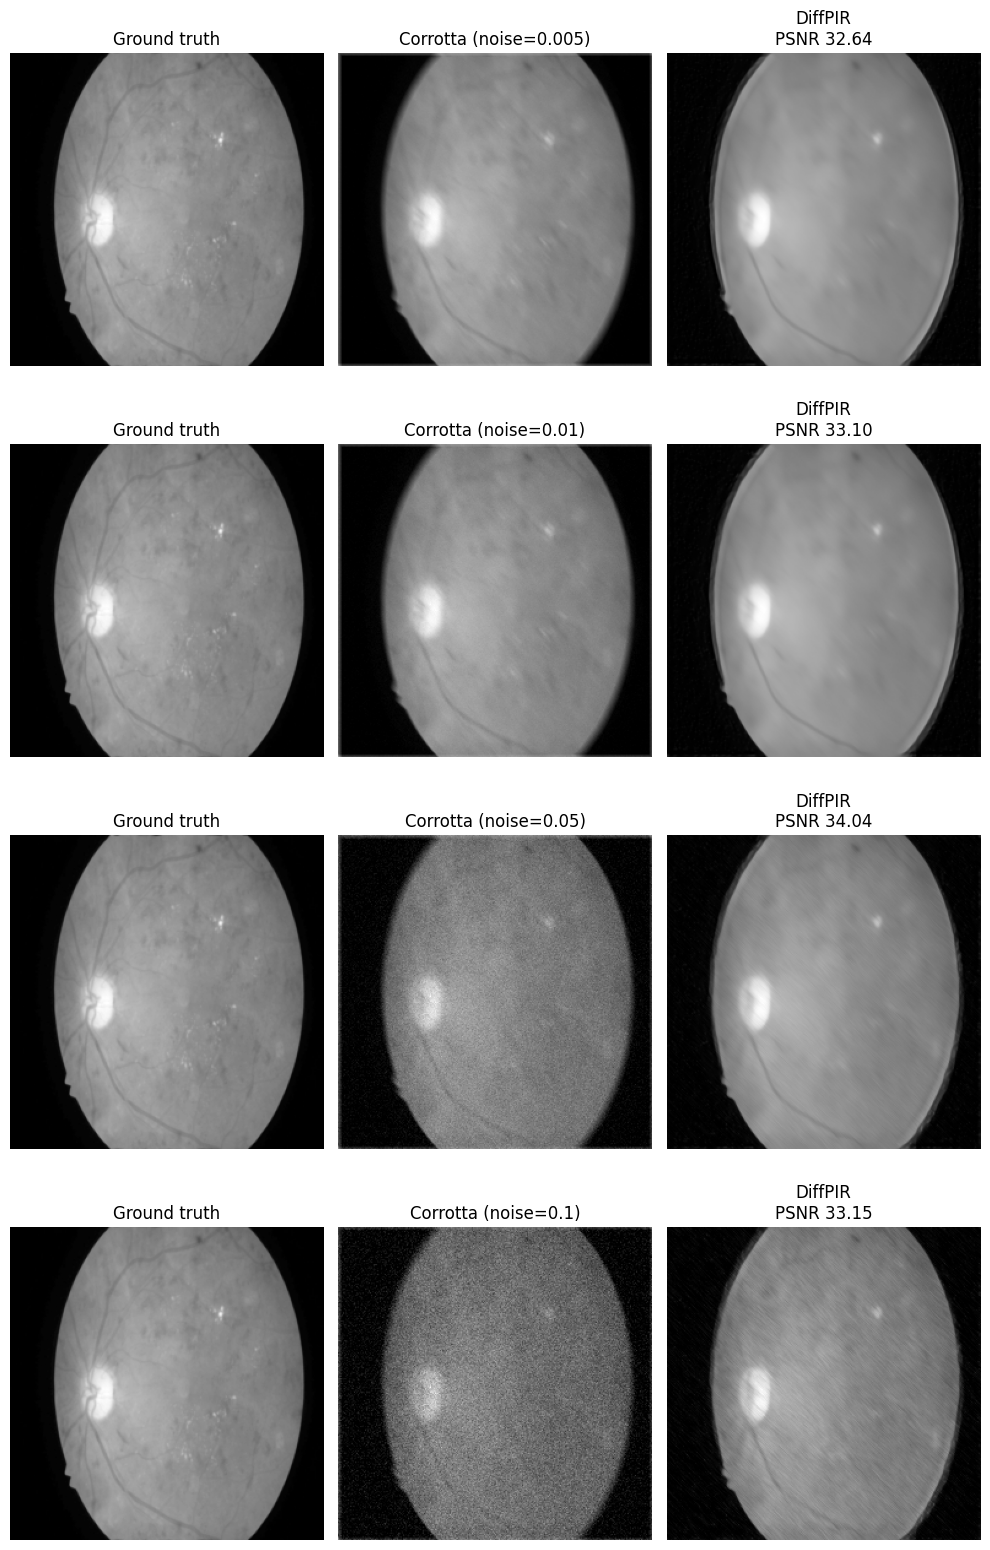

In [4]:
noise_levels = [0.005, 0.01, 0.05, 0.1]

x_true = test_dataset[0].unsqueeze(0).to(device)
x_true_01 = denormalize_to_01(x_true).cpu()

fig, axes = plt.subplots(len(noise_levels), 3, figsize=(10, 4 * len(noise_levels)))
print(f"{'Noise':<8}{'PSNR (dB)':>12}{'SSIM':>10}")

for r, nl in enumerate(noise_levels):
    torch.manual_seed(0)
    with torch.no_grad():
        y_delta = K(x_true) + nl * torch.randn_like(x_true)
    x_rec = diffpir_reconstruct(model, y_delta, K, alpha_bars, sample_steps=40, tau=0.5)

    y_01   = denormalize_to_01(y_delta).cpu()
    rec_01 = denormalize_to_01(x_rec).cpu()
    psnr = PSNR(rec_01, x_true_01)
    ssim = SSIM(rec_01, x_true_01)
    print(f"{nl:<8}{psnr:>12.3f}{ssim:>10.4f}")

    axes[r, 0].imshow(x_true_01.squeeze(), cmap='gray'); axes[r, 0].set_title('Ground truth'); axes[r, 0].axis('off')
    axes[r, 1].imshow(y_01.squeeze(), cmap='gray');      axes[r, 1].set_title(f'Corrotta (noise={nl})'); axes[r, 1].axis('off')
    axes[r, 2].imshow(rec_01.squeeze(), cmap='gray');    axes[r, 2].set_title(f'DiffPIR\nPSNR {psnr:.2f}'); axes[r, 2].axis('off')

plt.tight_layout(); plt.show()

# Risultati iniziali
Dopo aver effettuato il training si è testata la ricostruzione su una sola immagine, sui 4 diversi livelli di rumore e un tau prefissato di 0.5.

Si sono ottenuti i seguenti risultati:

| Noise | PSNR (dB) | SSIM   |
|-------|-----------|--------|
| 0.005 | 32.638    | 0.8591 |
| 0.01  | 33.098    | 0.8627 |
| 0.05  | 34.044    | 0.8555 |
| 0.1   | 33.154    | 0.7709 |

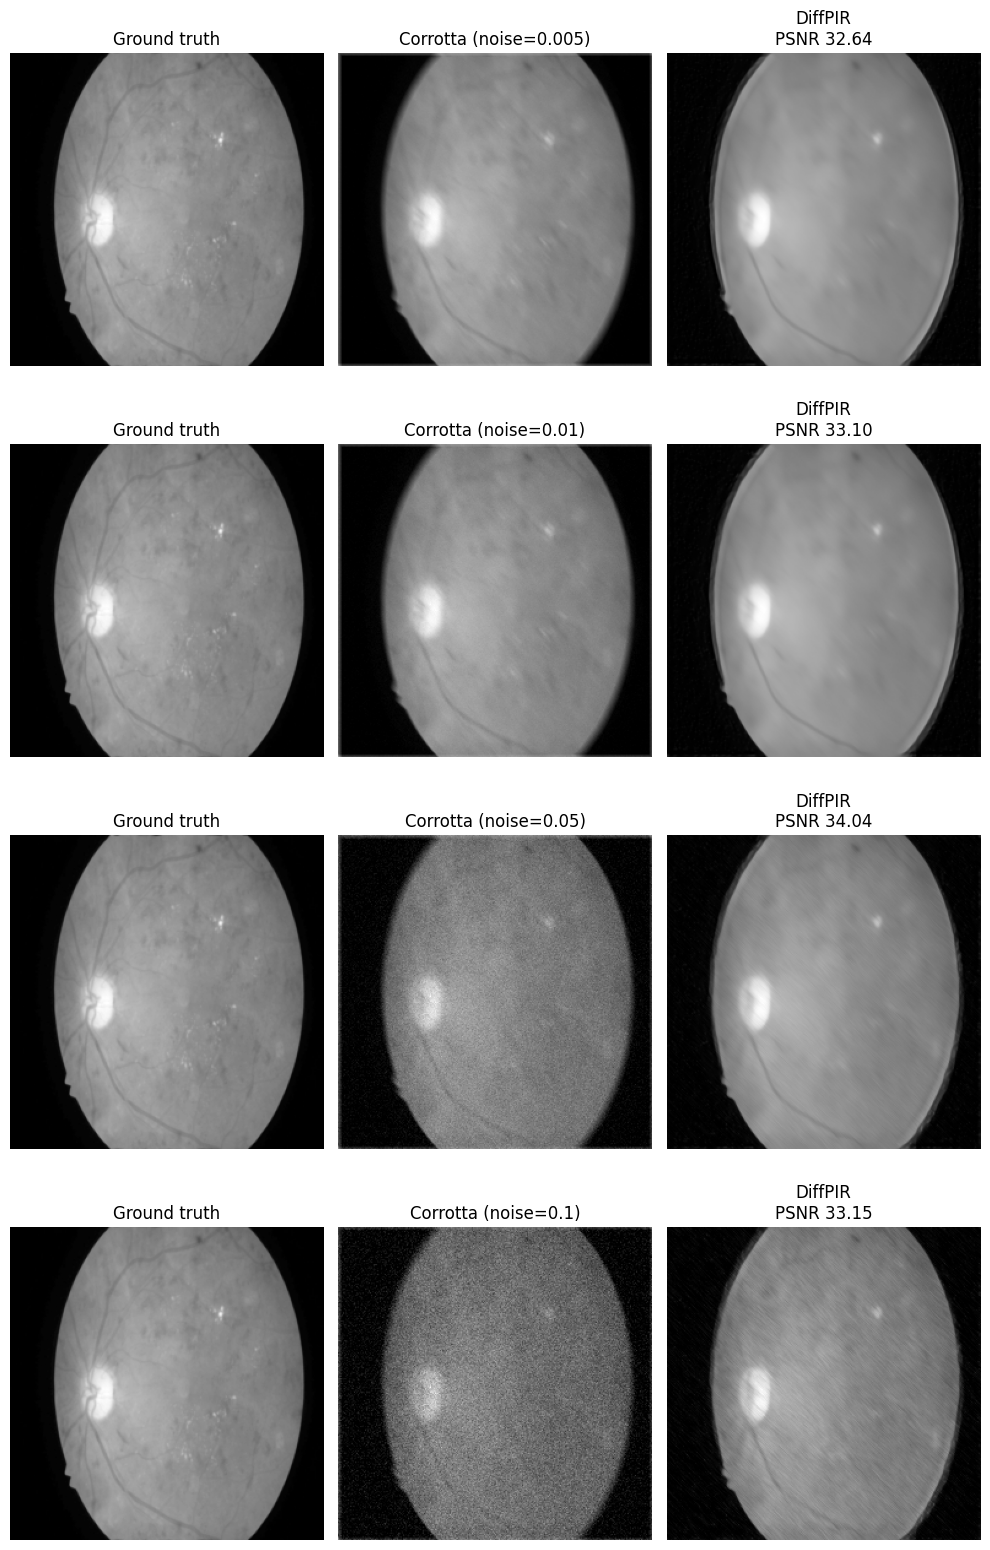

# Spiegazione/Osservazione Risultati

1) **Il DiffPIR recupera bene il deblur**

*   La ricostruzione riporta a fuoco la struttura della retina: il disco ottico (in bianco sulla sinistra) e i vasi principali restano riconoscibili rispetto alla misura corrotta. Il guadagno è più evidente ai livelli di rumore alti, dove la misura è quasi sommersa e la ricostruzione torna comunque pulita.

2.   **Robustezza al rumore**

*   Man mano che cresce il rumore (da 0.005 a 0.1) la misura peggiora visibilmente (l'ultima è praticamente sommersa dal rumore), ma la **ricostruzione DiffPIR rimane molto stabile**.
Il PSNR resta in una banda stretta, tra 32.638 e 34.044 dB, senza crolli al crescere del rumore. La SSIM si mantiene alta e quasi piatta fino a noise 0.05 (intorno a 0.855 e 0.863), per poi scendere a 0.7709 sul rumore massimo.
Questo conferma che il prior a diffusione assorbe bene il rumore: il denoiser 'sa' che le retine non sono rumorose e quindi lo rimuove in modo naturale.

3. **Andamento delle metriche rispetto al rumore**

*   A differenza di quanto ci si aspetterebbe, il PSNR non cala in modo monotono col rumore: è minimo a 0.005 (32.638) e massimo a 0.05 (34.044), per poi assestarsi a 33.154 a rumore 0.1.
*   La SSIM invece, più sensibile alla qualità strutturale fine, segue un andamento più 'classico': resta stabile ai primi tre livelli e poi cede al rumore massimo (0.7709). In altre parole il PSNR tiene anche a 0.1, ma i dettagli strutturali iniziano a soffrire.
*   La spiegazione sta nel **tau fissato a 0.5**. Questo valore si fida poco della misura, quindi a rumore basso (dove la misura sarebbe affidabile) la ricostruzione si appoggia troppo al prior e risulta più liscia, con PSNR leggermente più basso. A rumore alto invece 0.5 è vicino al tau ottimale per quel livello, e infatti la ricostruzione regge bene. Con la taratura di tau per livello di rumore questo andamento si riallinea.

*Si nota ancora un leggero alone/contorno luminoso sul bordo dell'ovale, riconducibile a un piccolo effetto di bordo dovuto al blur + data consistency. Il valore di tau usato qui è fisso a **0.5**, prima della taratura.*

# Taratura TAU
In questa fase si è cercato un livello di tau ottimale, in modo da eliminare il problema dell'alone che abbiamo riscontrato con tau fisso nell'immagine precedente. Sebbene in questa fase/cella non troviamo il tau ottimale per ogni livello di rumore, ci è necessaria per comprendere dopo quale livello di tau il modello collassa, e trovare quindi tutti i valori da usare successivamente


In [5]:
x_true = val_dataset[0].unsqueeze(0).to(device)
x_true_01 = denormalize_to_01(x_true).cpu()

nl = 0.01   # livello di rumore rappresentativo per la taratura
torch.manual_seed(0)
y_delta = K(x_true) + nl * torch.randn_like(x_true)   # stessa misura per tutti i tau

print(f"Taratura di tau (noise={nl})")
print(f"{'tau':>6}{'PSNR (dB)':>12}{'SSIM':>10}")
for tau in [0.3, 0.5, 0.7, 1.0]:
    x_rec = diffpir_reconstruct(model, y_delta, K, alpha_bars, sample_steps=40, tau=tau)
    rec01 = denormalize_to_01(x_rec).cpu()
    print(f"{tau:>6}{PSNR(rec01, x_true_01):>12.3f}{SSIM(rec01, x_true_01):>10.4f}")

Taratura di tau (noise=0.01)
   tau   PSNR (dB)      SSIM
   0.3      29.897    0.8615
   0.5      31.055    0.8803
   0.7      31.776    0.8886
   1.0      32.858    0.8984


Notiamo che le metriche aumentano all'aumentare del tau, inoltre con tau=1.0 sono ancora in salita. Motivo per cui magari non è ancora il risultato ottimale.
motivo per cui si provano valori maggiori.

| tau | PSNR (dB) | SSIM   |
|-----|-----------|--------|
| 0.3 | 29.897    | 0.8615 |
| 0.5 | 31.055    | 0.8803 |
| 0.7 | 31.776    | 0.8886 |
| 1.0 | 32.858    | 0.8984 |

In [6]:
print(f"{'tau':>6}{'PSNR (dB)':>12}{'SSIM':>10}")
for tau in [1.3, 1.6, 2.0, 2.5, 2.7, 3.0]:
    x_rec = diffpir_reconstruct(model, y_delta, K, alpha_bars, sample_steps=40, tau=tau)
    rec01 = denormalize_to_01(x_rec).cpu()
    print(f"{tau:>6}{PSNR(rec01, x_true_01):>12.3f}{SSIM(rec01, x_true_01):>10.4f}")

   tau   PSNR (dB)      SSIM
   1.3      32.655    0.8987
   1.6      32.213    0.8772
   2.0      32.566    0.8746
   2.5      12.495    0.2068
   2.7      11.968    0.1611
   3.0      11.175    0.1434


Notiamo che le metriche restano alte nella zona tra tau 1.0 e 1.3 (la SSIM ha il massimo proprio a 1.3), per poi calare. Il PSNR a tau=2.0 risale leggermente, ma è un comportamento poco affidabile: si trova subito prima del collasso del modello (a tau=2.5 le metriche crollano, con PSNR intorno a 12 e SSIM intorno a 0.21), quindi non rappresenta un vero ottimo ma un artefatto dovuto all'instabilità.

Da questa esplorazione non fissiamo quindi un singolo tau ottimale: il suo scopo è capire dove ha senso cercare. Il range utile resta sotto 1.6 circa, mentre oltre 2.0 il modello diventa instabile e va escluso. Il valore migliore di tau verrà poi scelto separatamente per ciascun livello di rumore nella sezione successiva, dato che dipende dal rumore presente nella misura.

| tau | PSNR (dB) | SSIM   |
|-----|-----------|--------|
| 1.3 | 32.655    | 0.8987 |
| 1.6 | 32.213    | 0.8772 |
| 2.0 | 32.566    | 0.8746 |
| 2.5 | 12.495    | 0.2068 |
| 2.7 | 11.968    | 0.1611 |
| 3.0 | 11.175    | 0.1434 |

# Taratura tau su diversi livelli di rumore

In questo caso per selezionare il tau ottimale per ogni livello di rumore, viene eseguito un test su 5 immagini per ogni livello.



In [7]:
import numpy as np

tau_grid = [0.3, 0.5, 0.7, 1.0, 1.3, 1.6]
noise_levels = [0.005, 0.01, 0.05, 0.1]
n_images = 5     # immagini su cui mediare per ogni (tau, noise)

best_tau = {}

print(f"Taratura di tau per ogni livello di rumore (media su {n_images} immagini)\n")

for nl in noise_levels:
    print(f"-- noise = {nl} --")
    print(f"{'tau':>6}{'PSNR medio':>13}{'SSIM medio':>13}")
    scores = []
    for tau in tau_grid:
        psnrs, ssims = [], []
        for idx in range(n_images):
            x_true = val_dataset[idx].unsqueeze(0).to(device)
            x_true_01 = denormalize_to_01(x_true).cpu()
            torch.manual_seed(idx)
            y_delta = K(x_true) + nl * torch.randn_like(x_true)
            x_rec = diffpir_reconstruct(model, y_delta, K, alpha_bars, sample_steps=40, tau=tau)
            rec01 = denormalize_to_01(x_rec).cpu()
            psnrs.append(PSNR(rec01, x_true_01))
            ssims.append(SSIM(rec01, x_true_01))
        p, s = np.mean(psnrs), np.mean(ssims)
        scores.append((tau, p, s))
        print(f"{tau:>6}{p:>13.3f}{s:>13.4f}")

    # tau migliore per questo livello di rumore (in base al PSNR)
    best = max(scores, key=lambda r: r[1])
    best_tau[nl] = best[0]
    print(f"  -> tau migliore: {best[0]} (PSNR {best[1]:.3f}, SSIM {best[2]:.4f})\n")

print("Riepilogo tau ottimale per livello di rumore:")
for nl, tau in best_tau.items():
    print(f"  noise={nl}: tau={tau}")

Taratura di tau per ogni livello di rumore (media su 5 immagini)

-- noise = 0.005 --
   tau   PSNR medio   SSIM medio
   0.3       30.583       0.8639
   0.5       31.603       0.8877
   0.7       32.345       0.8977
   1.0       33.289       0.9060
   1.3       32.639       0.8961
   1.6       32.987       0.8976
  -> tau migliore: 1.0 (PSNR 33.289, SSIM 0.9060)

-- noise = 0.01 --
   tau   PSNR medio   SSIM medio
   0.3       30.750       0.8657
   0.5       31.857       0.8898
   0.7       32.571       0.8997
   1.0       33.455       0.9070
   1.3       33.167       0.9007
   1.6       33.077       0.8941
  -> tau migliore: 1.0 (PSNR 33.455, SSIM 0.9070)

-- noise = 0.05 --
   tau   PSNR medio   SSIM medio
   0.3       31.530       0.8713
   0.5       32.382       0.8835
   0.7       32.864       0.8767
   1.0       33.075       0.8496
   1.3       32.863       0.8126
   1.6       32.216       0.7677
  -> tau migliore: 1.0 (PSNR 33.075, SSIM 0.8496)

-- noise = 0.1 --
   tau   PSN

Effettuando la taratura su diversi livelli di rumore (media su 5 immagini di validation), si sono ottenuti i seguenti risultati:

**Noise = 0.005**
| tau | PSNR medio | SSIM medio |
|-----|------------|------------|
| 0.3 | 30.583     | 0.8639     |
| 0.5 | 31.603     | 0.8877     |
| 0.7 | 32.345     | 0.8977     |
| 1.0 | 33.289     | 0.9060     |
| 1.3 | 32.639     | 0.8961     |
| 1.6 | 32.987     | 0.8976     |

tau migliore: 1.0
PSNR = 33.289, SSIM = 0.9060

**Noise = 0.01**
| tau | PSNR medio | SSIM medio |
|-----|------------|------------|
| 0.3 | 30.750     | 0.8657     |
| 0.5 | 31.857     | 0.8898     |
| 0.7 | 32.571     | 0.8997     |
| 1.0 | 33.455     | 0.9070     |
| 1.3 | 33.167     | 0.9007     |
| 1.6 | 33.077     | 0.8941     |

tau migliore: 1.0
PSNR = 33.455, SSIM = 0.9070

**Noise = 0.05**
| tau | PSNR medio | SSIM medio |
|-----|------------|------------|
| 0.3 | 31.530     | 0.8713     |
| 0.5 | 32.382     | 0.8835     |
| 0.7 | 32.864     | 0.8767     |
| 1.0 | 33.075     | 0.8496     |
| 1.3 | 32.863     | 0.8126     |
| 1.6 | 32.216     | 0.7677     |

tau migliore: 1.0
PSNR = 33.075, SSIM = 0.8496

**Noise = 0.1**
| tau | PSNR medio | SSIM medio |
|-----|------------|------------|
| 0.3 | 31.607     | 0.8514     |
| 0.5 | 31.591     | 0.7989     |
| 0.7 | 30.978     | 0.7227     |
| 1.0 | 29.716     | 0.6168     |
| 1.3 | 28.522     | 0.5324     |
| 1.6 | 27.308     | 0.4590     |

tau migliore: 0.3
PSNR = 31.607, SSIM = 0.8514

**Riepilogo**
| noise | tau |
|-------|-----|
| 0.005 | 1.0 |
| 0.01  | 1.0 |
| 0.05  | 1.0 |
| 0.1   | 0.3 |

Il tau ottimale rimane alto (1.0) per i primi tre livelli di rumore, per poi scendere a 0.3 con il rumore più forte.

*   Con **rumore basso/medio** (da 0.005 a 0.05): la misura è abbastanza affidabile, quindi conviene un tau alto (1.0). Si rimane agganciati ai dati recuperando molto deblur.
*   Con **rumore alto** (0.1): la misura risulta inquinata, e con un tau alto staremmo praticamente 'inseguendo' il rumore. Infatti a questo livello le metriche peggiorano in modo costante all'aumentare del tau, motivo per cui conviene il tau più basso (0.3) che si affida di più al prior.

# Valutazione su Test


In [9]:
import numpy as np, json
from tqdm.auto import tqdm

n_images = len(test_dataset)   # 600
best_tau = {0.005: 1.0, 0.01: 1.0, 0.05: 1.0, 0.1: 0.3}
noise_levels = [0.005, 0.01, 0.05, 0.1]

ckpt_eval  = weights_dir / 'eval_diffpir.json'   # su Drive: persiste tra sessioni
save_every = 20

# Ripresa nel caso in cui vi sia interruzione
if ckpt_eval.exists():
    state = json.load(open(ckpt_eval))
    start_idx = state['next_idx']
    results = {float(k): v for k, v in state['results'].items()}
    print(f'Ripresa dall\'immagine {start_idx}/{n_images}')
else:
    start_idx = 0
    results = {nl: {'psnr': [], 'ssim': []} for nl in noise_levels}
    print('Valutazione da zero')

def save_ckpt(next_idx):
    state = {'next_idx': next_idx,
             'results': {str(nl): results[nl] for nl in noise_levels}}
    tmp = ckpt_eval.with_suffix('.tmp')
    json.dump(state, open(tmp, 'w'))
    tmp.replace(ckpt_eval)          # scrittura atomica

for idx in tqdm(range(start_idx, n_images), initial=start_idx, total=n_images,
                desc='Valutazione test'):
    x_true = test_dataset[idx].unsqueeze(0).to(device)
    x_true_01 = denormalize_to_01(x_true).cpu()
    for nl in noise_levels:
        tau = best_tau[nl]
        torch.manual_seed(idx)
        y_delta = K(x_true) + nl * torch.randn_like(x_true)
        x_rec = diffpir_reconstruct(model, y_delta, K, alpha_bars, sample_steps=40, tau=tau)
        rec01 = denormalize_to_01(x_rec).cpu()
        results[nl]['psnr'].append(float(PSNR(rec01, x_true_01)))
        results[nl]['ssim'].append(float(SSIM(rec01, x_true_01)))
    if (idx + 1) % save_every == 0:
        save_ckpt(idx + 1)

save_ckpt(n_images)   # salvataggio finale

print(f"\n{'Noise':<8}{'tau':>6}{'PSNR medio':>13}{'SSIM medio':>13}")
for nl in noise_levels:
    p = np.mean(results[nl]['psnr']); s = np.mean(results[nl]['ssim'])
    print(f"{nl:<8}{best_tau[nl]:>6}{p:>13.3f}{s:>13.4f}")

Valutazione da zero


Valutazione test:   0%|          | 0/600 [00:00<?, ?it/s]


Noise      tau   PSNR medio   SSIM medio
0.005      1.0       33.848       0.9121
0.01       1.0       34.092       0.9122
0.05       1.0       33.653       0.8415
0.1        0.3       31.876       0.7930


La valutazione finale è stata effettuata su tutte le 600 immagini di test, usando per ciascun livello di rumore il tau ottimale individuato in fase di validation.

**Test su 600 immagini (tau ottimale per livello)**
| Noise | tau | PSNR medio | SSIM medio |
|-------|-----|------------|------------|
| 0.005 | 1.0 | 33.848     | 0.9121     |
| 0.01  | 1.0 | 34.092     | 0.9122     |
| 0.05  | 1.0 | 33.653     | 0.8415     |
| 0.1   | 0.3 | 31.876     | 0.7930     |

1) **Stima affidabile delle prestazioni**
La media su 600 immagini smussa i casi più difficili e fornisce un valore stabile, che non dipende più dalla particolare immagine scelta come invece accadeva nei test su una sola immagine.

2) **Robustezza su tutti i livelli di rumore**
Usando il tau ottimale per ciascun livello, il metodo regge bene lungo tutta la scala di rumore. Anche a noise = 0.1 le metriche restano dignitose (PSNR 31.876, SSIM 0.7930), senza il crollo che si osservava usando un tau fisso non adattato al rumore. Si nota comunque che la SSIM degrada più del PSNR all'aumentare del rumore (il PSNR resta intorno a 34 fino a 0.05, mentre la SSIM scende da 0.91 a 0.84), segno che la qualità strutturale fine è la prima a risentirne.

3) **Importanza della taratura adattiva di tau**
Il confronto conferma che il tau ottimale dipende dal livello di rumore: a rumore basso e medio conviene un tau alto (1.0), che si fida della misura e recupera molto deblur; a rumore alto conviene un tau più basso (0.3), che si affida maggiormente al prior di diffusione evitando di inseguire il rumore.

# Visualizzazione del tau ottimale con la stessa immagine

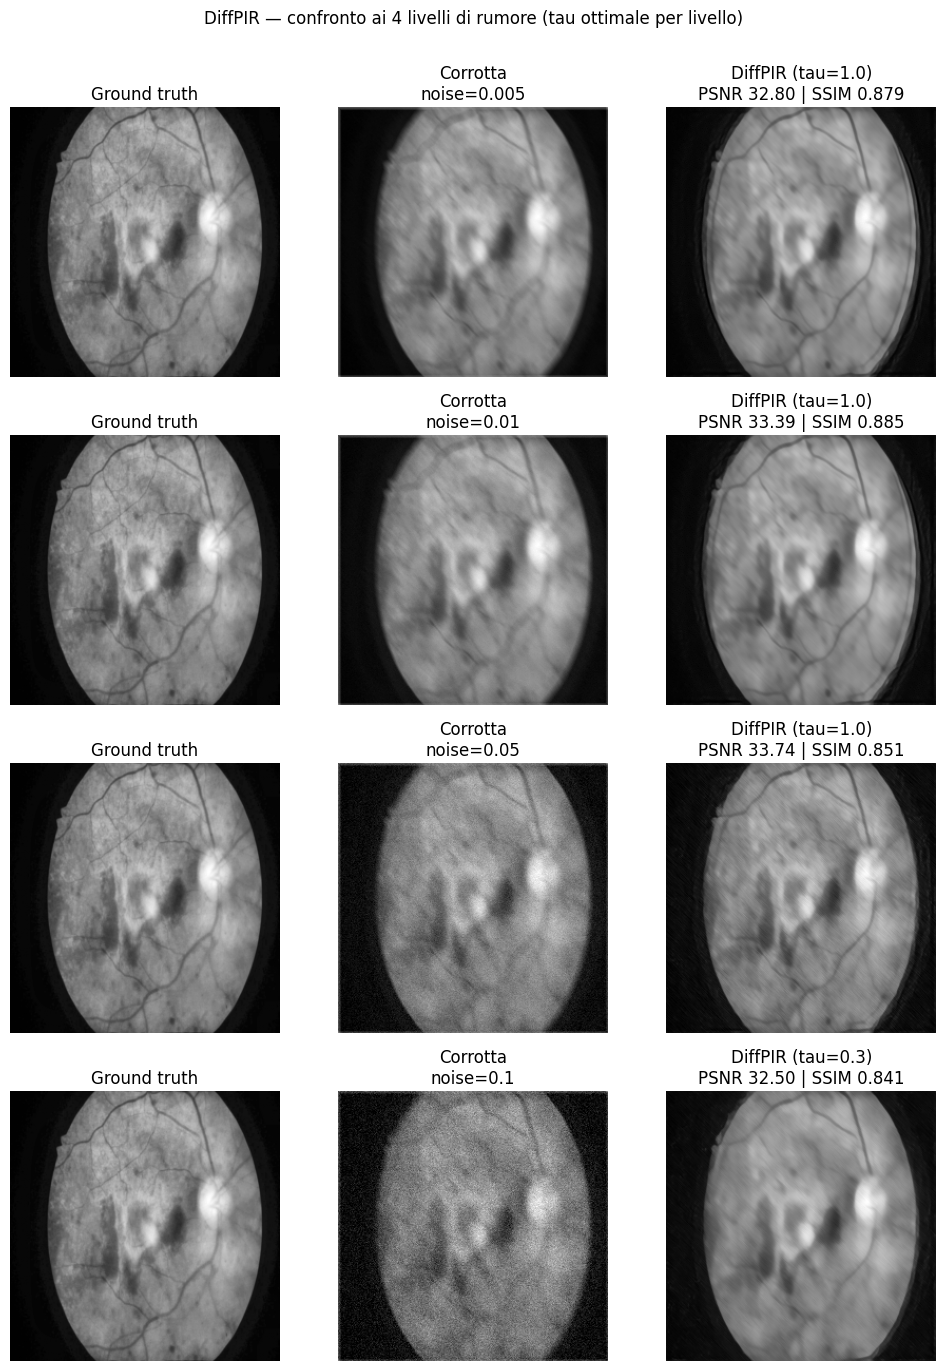

In [15]:
import matplotlib.pyplot as plt

# tau ottimale per livello
best_tau = {0.005: 1.0, 0.01: 1.0, 0.05: 1.0, 0.1: 0.3}
noise_levels = [0.005, 0.01, 0.05, 0.1]

# Immagine di test fissa
idx = 1
x_true = test_dataset[idx].unsqueeze(0).to(device)
x_true_01 = denormalize_to_01(x_true).cpu()

fig, axes = plt.subplots(len(noise_levels), 3, figsize=(10, 3.4 * len(noise_levels)))

for r, nl in enumerate(noise_levels):
    tau = best_tau[nl]
    torch.manual_seed(idx)
    with torch.no_grad():
        y_delta = K(x_true) + nl * torch.randn_like(x_true)
    x_rec = diffpir_reconstruct(model, y_delta, K, alpha_bars, sample_steps=40, tau=tau)

    y_01   = denormalize_to_01(y_delta).cpu()
    rec_01 = denormalize_to_01(x_rec).cpu()
    psnr   = PSNR(rec_01, x_true_01)
    ssim   = SSIM(rec_01, x_true_01)

    axes[r, 0].imshow(x_true_01.squeeze(), cmap='gray')
    axes[r, 0].set_title('Ground truth'); axes[r, 0].axis('off')
    axes[r, 1].imshow(y_01.squeeze(), cmap='gray')
    axes[r, 1].set_title(f'Corrotta\nnoise={nl}'); axes[r, 1].axis('off')
    axes[r, 2].imshow(rec_01.squeeze(), cmap='gray')
    axes[r, 2].set_title(f'DiffPIR (tau={tau})\nPSNR {psnr:.2f} | SSIM {ssim:.3f}')
    axes[r, 2].axis('off')

plt.suptitle('DiffPIR — confronto ai 4 livelli di rumore (tau ottimale per livello)', y=1.005)
plt.tight_layout(); plt.show()

Ecco i risultati sui 4 livelli diversi di rumore e con rispettivo tau ottimale

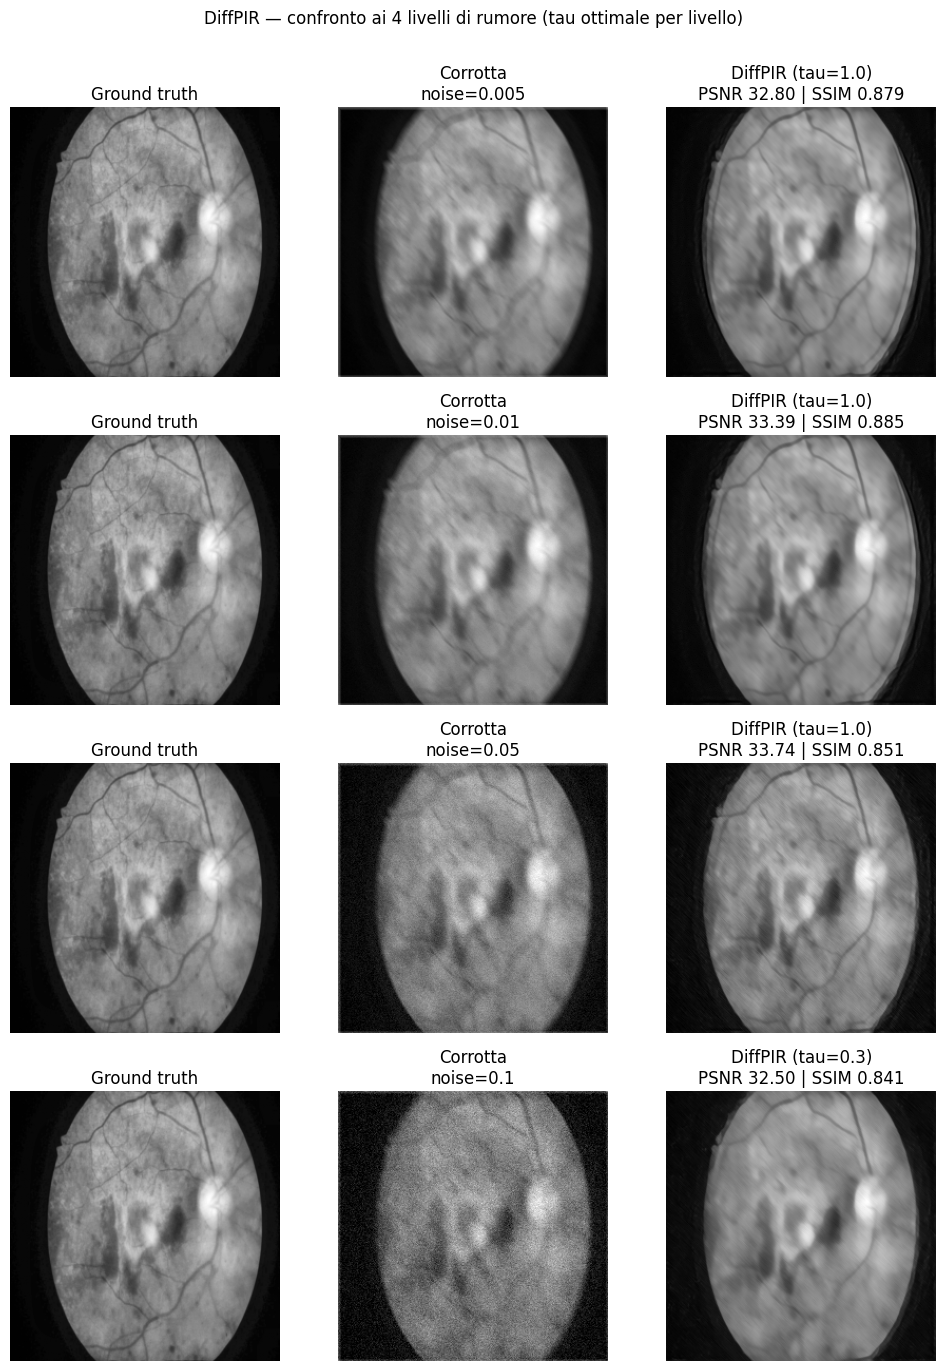

# Tau ottimale vs livello di rumore


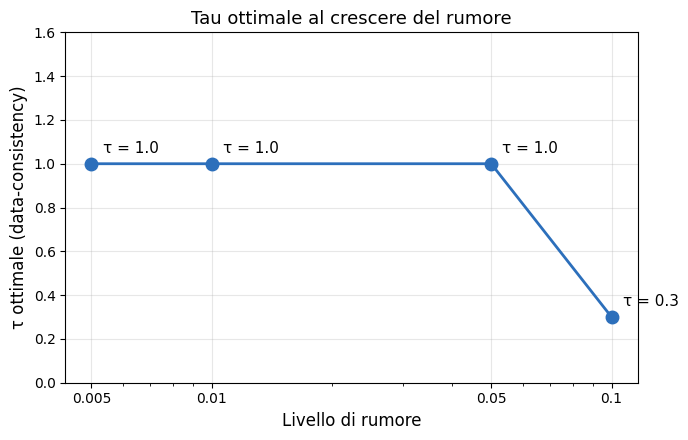

In [12]:
import matplotlib.pyplot as plt

# Risultati della taratura per livello di rumore
noise_levels = [0.005, 0.01, 0.05, 0.1]
best_tau = [1.0, 1.0, 1.0, 0.3]

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(noise_levels, best_tau, 'o-', color='#2c6fbb', linewidth=2, markersize=9)

# Etichette del valore di tau accanto a ogni punto
for nl, tau in zip(noise_levels, best_tau):
    ax.annotate(f'τ = {tau}', (nl, tau),
                textcoords='offset points', xytext=(8, 8), fontsize=11)

ax.set_xscale('log')   # i livelli di rumore sono su scala logaritmica
ax.set_xticks(noise_levels)
ax.set_xticklabels([str(nl) for nl in noise_levels])
ax.set_xlabel('Livello di rumore', fontsize=12)
ax.set_ylabel('τ ottimale (data-consistency)', fontsize=12)
ax.set_title('Tau ottimale al crescere del rumore', fontsize=13)
ax.grid(alpha=0.3)
ax.set_ylim(0, 1.6)

plt.tight_layout()
plt.show()

# Metriche vs Livello di Rumore

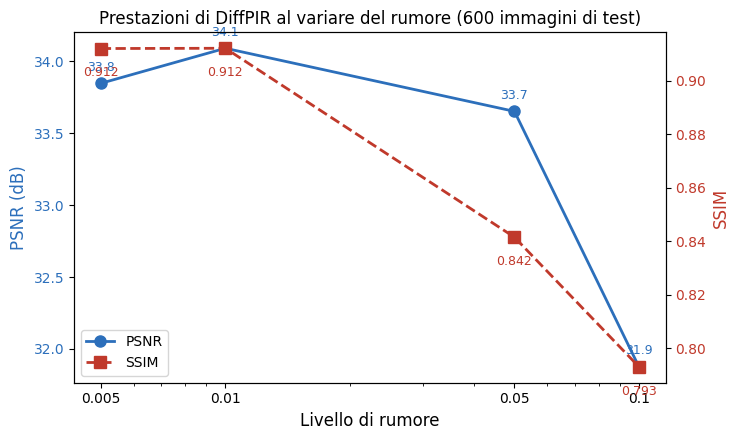

In [13]:
import matplotlib.pyplot as plt

# Valori finali della valutazione su 600 immagini
noise_levels = [0.005, 0.01, 0.05, 0.1]
psnr_vals    = [33.848, 34.092, 33.653, 31.876]
ssim_vals    = [0.9121, 0.9122, 0.8415, 0.7930]

fig, ax1 = plt.subplots(figsize=(7.5, 4.5))

# Asse sinistro: PSNR
color1 = '#2c6fbb'
ax1.plot(noise_levels, psnr_vals, 'o-', color=color1, linewidth=2, markersize=8, label='PSNR')
ax1.set_xlabel('Livello di rumore', fontsize=12)
ax1.set_ylabel('PSNR (dB)', color=color1, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xscale('log')
ax1.set_xticks(noise_levels)
ax1.set_xticklabels([str(nl) for nl in noise_levels])

# Asse destro: SSIM
ax2 = ax1.twinx()
color2 = '#c0392b'
ax2.plot(noise_levels, ssim_vals, 's--', color=color2, linewidth=2, markersize=8, label='SSIM')
ax2.set_ylabel('SSIM', color=color2, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color2)

# Etichette dei valori sui punti
for nl, p in zip(noise_levels, psnr_vals):
    ax1.annotate(f'{p:.1f}', (nl, p), textcoords='offset points', xytext=(0, 9),
                 fontsize=9, color=color1, ha='center')
for nl, s in zip(noise_levels, ssim_vals):
    ax2.annotate(f'{s:.3f}', (nl, s), textcoords='offset points', xytext=(0, -20),
                 fontsize=9, color=color2, ha='center')

plt.title('Prestazioni di DiffPIR al variare del rumore (600 immagini di test)', fontsize=12)
fig.tight_layout()

# Legenda
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left', fontsize=10)

plt.show()